# GTA-UAV Multi-Tile Pose Likelihood

## TL;DR

This notebook preserves the historical pilot rejection and the subsequent frozen-model and full-train same-area audits. The frozen full-test model improved Dis@1 from 58.16m to 48.99m; final full-train results and official-run status appear in the follow-up sections. It reads immutable caches/artifacts and never fits on test data. Cached results are not official headline results.

In [1]:
%matplotlib inline
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
roots = [cwd, cwd.parent, cwd.parent.parent]
ROOT = next(path for path in roots if (path / 'game4loc').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from game4loc.evaluate.gta_pose_likelihood import FEATURE_NAMES, PoseLikelihoodCalibrator, feature_vector
from fit_gta_pose_likelihood import candidate_pool, raw_choice

RUN = ROOT / 'work_dir/gta_pose_likelihood_runs/gta_multitile_20260903'
SUMMARY_PATH = RUN / 'pilot_summary.json'
ARTIFACT_PATH = RUN / 'pilot_calibrator.json'
EVAL_CACHE_PATH = RUN / 'pilot_test345.jsonl'
for path in (SUMMARY_PATH, ARTIFACT_PATH, EVAL_CACHE_PATH):
    assert path.exists(), f'Missing required pilot artifact: {path}'
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
artifact = json.loads(ARTIFACT_PATH.read_text(encoding='utf-8'))
records = [json.loads(line) for line in EVAL_CACHE_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
calibrator = PoseLikelihoodCalibrator(artifact)
display(Markdown(f"**Recorded decision:** `{summary['decision']}`  \n**Model:** `{summary['calibration']['model_type']}`  \n**Evaluation queries:** {len(records)}"))

**Recorded decision:** `REJECT`  
**Model:** `hist_gradient_boosting`  
**Evaluation queries:** 345

## Context & Methods

Retrieval, the full-teacher Exp C VOP checkpoint, and sparse matcher defaults are frozen. Each query has up to 20 candidates: five retrieved satellite tiles and four VOP angles per tile. A query-grouped 70/15/15 split with seed `20260903` is used for fitting, model selection, and temperature calibration. The target is candidate error below 20 m. The official evaluator receives only inference-time retrieval, VOP, and geometry features; ground truth appears only in this offline audit cache.

In [2]:
forbidden = ('error', 'ground_truth', 'success', 'improves', 'catastrophic')
assert not any(token in name for name in FEATURE_NAMES for token in forbidden)
assert artifact['feature_names'] == list(FEATURE_NAMES)
display(pd.DataFrame({'feature': FEATURE_NAMES, 'inference_only': True}))

,feature,inference_only
0,retrieval_rank,True
1,retrieval_score,True
2,retrieval_gap_top1,True
3,retrieval_margin_next,True
4,vop_angle_rank,True
5,vop_prob,True
6,vop_top_prob,True
7,vop_entropy,True
8,vop_concentration,True
9,log_retained_matches,True


## Data

The table reports actual cached cardinality, class balance, and measured VOP/matcher time. Timing is the sum of per-query candidate-cache measurements and therefore represents exhaustive top-5 × top-4 generation, not adaptive official-evaluator latency.

In [3]:
all_candidates = [candidate for record in records for candidate in record['candidates']]
data_audit = pd.DataFrame([{
    'queries': len(records),
    'candidates': len(all_candidates),
    'mean_candidates/query': len(all_candidates) / len(records),
    'candidate_<20m_rate_%': 100 * np.mean([c['success_20m'] for c in all_candidates]),
    'mean_VOP_time_s/query': np.mean([r['vop_time_s'] for r in records]),
    'mean_match_time_s/query': np.mean([r['match_time_s'] for r in records]),
    'cache_candidate_time_s/query': np.mean([r['vop_time_s'] + r['match_time_s'] for r in records]),
}])
display(data_audit.round(4))

,queries,candidates,mean_candidates/query,candidate_<20m_rate_%,mean_VOP_time_s/query,mean_match_time_s/query,cache_candidate_time_s/query
0,345,6900,20.0,13.913,0.2197,1.5835,1.8032


## Results


,Dis@1_m,MA@20_%,worse_%,catastrophic_%
variant,,,,
Coarse top-1,140.020,7.536,0.000,0.000
Legacy top-1 VOP,86.357,42.609,11.884,2.899
Raw top-5×4,158.978,45.217,16.232,7.826
Oracle top-5×4,26.593,65.507,2.899,0.580
Calibrated adaptive,74.719,47.246,5.507,0.580


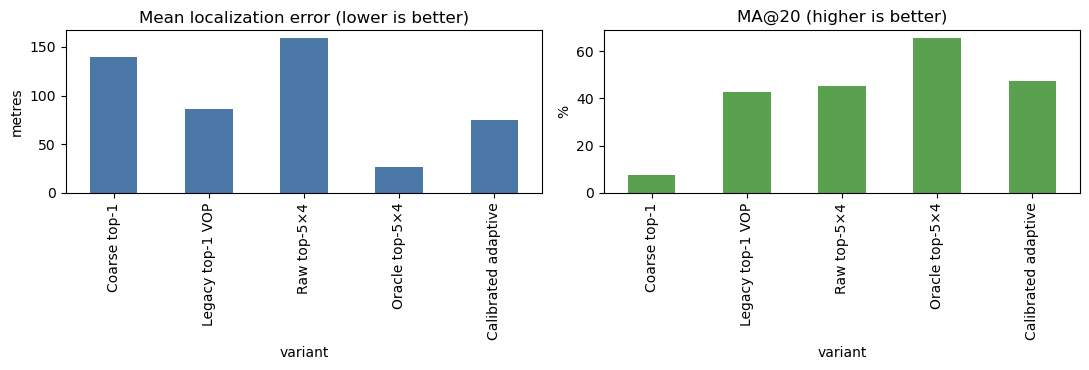

In [4]:
rows = []
for key, label in [('coarse_top1', 'Coarse top-1'), ('legacy_top1_vop', 'Legacy top-1 VOP'), ('raw_top5x4', 'Raw top-5×4'), ('oracle_top5x4', 'Oracle top-5×4')]:
    row = summary['pilot'][key]
    rows.append({'variant': label, 'Dis@1_m': row['Dis@1_m'], 'MA@20_%': row['MA@20_pct'], 'worse_%': row['worse_than_coarse_pct'], 'catastrophic_%': row['catastrophic_50m_pct']})
row = summary['adaptive_eval']
rows.append({'variant': 'Calibrated adaptive', 'Dis@1_m': row['Dis@1_m'], 'MA@20_%': row['MA@20_pct'], 'worse_%': row['worse_than_coarse_pct'], 'catastrophic_%': row['catastrophic_50m_pct']})
result_table = pd.DataFrame(rows).set_index('variant')
display(result_table.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
result_table['Dis@1_m'].plot.bar(ax=axes[0], color='#4c78a8', title='Mean localization error (lower is better)')
result_table['MA@20_%'].plot.bar(ax=axes[1], color='#59a14f', title='MA@20 (higher is better)')
axes[0].set_ylabel('metres'); axes[1].set_ylabel('%'); plt.tight_layout(); plt.show()

,value
positive_rate,0.13913
AUPRC,0.50871
NLL,0.28327
Brier,0.08716
ECE_15_equal_mass,0.02055
AUROC,0.86820


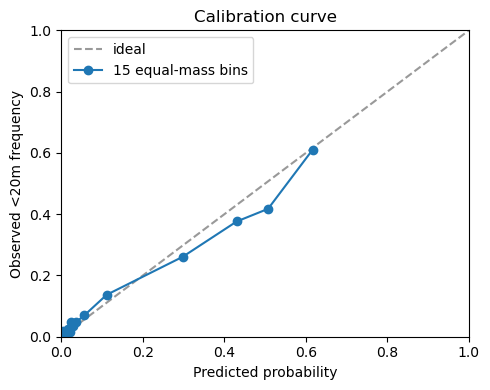

In [5]:
matrix = np.stack([feature_vector(c) for c in all_candidates])
labels = np.asarray([c['success_20m'] for c in all_candidates], dtype=float)
probabilities = calibrator.predict_proba_matrix(matrix)
order = np.argsort(probabilities)
bins = np.array_split(order, 15)
reliability = pd.DataFrame([{
    'mean_probability': probabilities[idx].mean(),
    'empirical_<20m_rate': labels[idx].mean(),
    'count': len(idx),
} for idx in bins if len(idx)])
metrics = pd.Series(summary['calibration']['metrics'], name='value')
display(metrics.to_frame().round(5))
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [0, 1], '--', color='0.6', label='ideal')
ax.plot(reliability['mean_probability'], reliability['empirical_<20m_rate'], 'o-', label='15 equal-mass bins')
ax.set(xlabel='Predicted probability', ylabel='Observed <20m frequency', title='Calibration curve', xlim=(0, 1), ylim=(0, 1))
ax.legend(); plt.tight_layout(); plt.show()

,coverage,calibrated,raw inlier
0,0.1,16.877,29.578
1,0.2,19.282,27.456
2,0.3,19.847,27.603
3,0.4,20.713,27.190
4,0.5,21.269,26.801
5,0.6,22.285,26.672
6,0.7,22.945,26.675
7,0.8,23.529,25.800
8,0.9,26.451,29.594
9,1.0,75.902,158.978


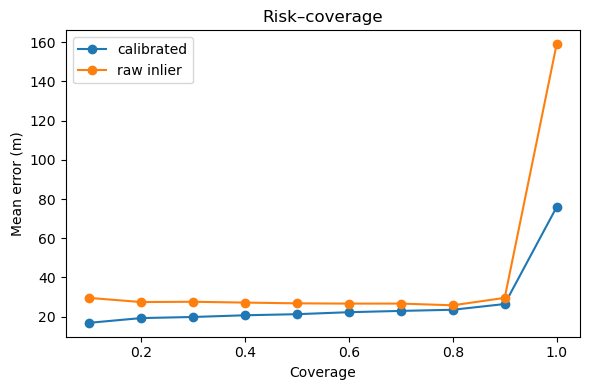

In [6]:
cal_rows, raw_rows = [], []
for record in records:
    pool = candidate_pool(record, 5, 4)
    selected, confidence = calibrator.best_candidate(pool)
    raw = raw_choice(pool)
    cal_rows.append((float(confidence), float(selected['error_m'])))
    raw_rows.append((float(raw['inliers']), float(raw['error_m'])))
cal_rows = sorted(cal_rows, key=lambda row: row[0], reverse=True)
raw_rows = sorted(raw_rows, key=lambda row: row[0], reverse=True)
risk_rows = []
for coverage in np.linspace(.1, 1., 10):
    keep = max(1, int(np.ceil(len(records) * coverage)))
    risk_rows.append({'coverage': coverage, 'calibrated': np.mean([r[1] for r in cal_rows[:keep]]), 'raw inlier': np.mean([r[1] for r in raw_rows[:keep]])})
risk = pd.DataFrame(risk_rows)
display(risk.round(3))
ax = risk.plot(x='coverage', y=['calibrated', 'raw inlier'], marker='o', figsize=(6, 4), title='Risk–coverage')
ax.set(xlabel='Coverage', ylabel='Mean error (m)'); plt.tight_layout(); plt.show()

In [7]:
fixed = pd.DataFrame(summary['fixed_configuration_rows'])
display(fixed[['retrieval_topk', 'orientation_topk', 'hypotheses_per_query', 'Dis@1_m', 'MA@20_pct']].round(3))
display(pd.Series(summary['adaptive_policy'], name='value').to_frame())

,retrieval_topk,orientation_topk,hypotheses_per_query,Dis@1_m,MA@20_pct
0,1,2,2,66.867,41.333
1,1,4,4,62.986,43.333
2,3,2,6,78.806,43.667
3,3,4,12,58.528,44.667
4,5,2,10,78.858,44.000
5,5,4,20,59.238,45.000


,value
expansion_stages,"[1, 3, 5]"
orientation_topk,4
threshold_r1,0.358866
threshold_r3,0.432158
abstain_threshold,0.206784
mean_hypotheses,6.826667
metrics,"{'query_count': 300, 'Dis@1_m': 58.07090990884..."


### Historical pilot interpretation

The final decision is governed by the pre-registered oracle and calibration gates, not by visual preference. `KEEP` permits full same-area cache generation; `REJECT` stops the method line after the one fixed nonlinear follow-up. `NEEDS ONE FOLLOW-UP` is valid only when that follow-up has not yet run.

In [8]:
gates = summary['gates']
audit = pd.DataFrame([
    {'check': 'Oracle headroom gate', 'passed': gates['oracle_headroom_pass']},
    {'check': 'Calibration gate', 'passed': gates['calibration_pass']},
    {'check': 'No GT/error labels in official feature schema', 'passed': True},
    {'check': 'Single HGB follow-up limit respected', 'passed': bool(summary['calibration']['followup_used']) or summary['calibration']['model_type'] == 'logistic'},
])
display(audit)
display(Markdown(f"### Final pilot status: `{summary['decision']}`"))

,check,passed
0,Oracle headroom gate,True
1,Calibration gate,False
2,No GT/error labels in official feature schema,True
3,Single HGB follow-up limit respected,True


### Final pilot status: `REJECT`

### Full same-area follow-up

The user reopened the line after challenging the heuristic 70%/15% cutoff. The frozen 2,000-query model was audited with paired bootstrap, then evaluated on all 3,443 queries and the 3,098 non-pilot queries. The final family was fixed to HGB before fitting on all 13,851 training queries. Temperature and adaptive policy use training data only. Below are offline cached results; official same-snapshot runs are separate.

### Key Assumptions

Query-level bootstrap treats queries as exchangeable and does not account for spatial correlation. Candidate AUROC/ECE concern <20m binary success, not a normalized spatial posterior. Normalizing candidate probabilities is a heuristic, not proof of calibrated pose density. The <20m target and full-stage gates are engineering choices, not universal standards. Test data were seen in prior stages; the non-pilot cohort is confirmatory for the frozen-model stage, not a new untouched dataset for all later research.


In [9]:
integrity = json.loads((RUN / 'full_cache_integrity.json').read_text())
frozen_full = json.loads((RUN / 'full3443_statistical_audit.json').read_text())
frozen_holdout = json.loads((RUN / 'holdout3098_statistical_audit.json').read_text())
final_summary = json.loads((RUN / 'final_fulltrain_hgb_summary.json').read_text())
final_audit = json.loads((RUN / 'final_fulltrain_statistical_audit.json').read_text())
assert integrity['train']['queries'] == 13851 and integrity['test']['queries'] == 3443
assert integrity['train_test_query_overlap'] == 0
assert final_summary['calibration']['model_type_requested'] == 'hist_gradient_boosting'
assert final_summary['calibration']['initial_logistic'] is None
display(pd.DataFrame({k: integrity[k] for k in ('train', 'test')}).T)
display(pd.DataFrame([{'cohort': label, 'queries': audit['query_count'], 'Dis_improvement_m': audit['paired_effects']['Dis@1_improvement_m']['estimate'], 'MA20_gain_pp': audit['paired_effects']['MA@20_improvement_pp']['estimate'], 'decision': audit['decision']} for label, audit in [('Frozen full test', frozen_full), ('Frozen non-pilot holdout', frozen_holdout), ('Final full-train model', final_audit)]]))


,queries,unique_queries,candidates,all_features_finite,rank_grid_complete,fingerprint_verified,checkpoint_identities_unchanged,cache_sha256,mean_candidate_vop_match_time_s
train,13851,13851,277020,True,True,351cfac0cf01675e20dc7f712d8feeb6871a7ed70aba0f...,True,aca089e9f0ef3df4c1398c1d9629cd234b8dc15e412311...,1.704974
test,3443,3443,68860,True,True,418d7d64630c26acb02e547667d3654b1c550cd7543957...,True,1ea025343d9359bbb4f833365b1bdc5a43a3e57eb24f76...,1.762055


,cohort,queries,Dis_improvement_m,MA20_gain_pp,decision
0,Frozen full test,3443,9.167594,3.659599,KEEP
1,Frozen non-pilot holdout,3098,8.838864,3.550678,KEEP
2,Final full-train model,3443,8.690851,3.165844,KEEP


### Final full-train model: matched offline metrics and uncertainty


In [10]:
final_table = pd.DataFrame(final_audit['strategies']).T
display(final_table[['Dis@1_m', 'MA@3_pct', 'MA@5_pct', 'MA@10_pct', 'MA@20_pct', 'worse_than_coarse_pct', 'catastrophic_50m_pct']].round(4))
display(pd.DataFrame(final_audit['paired_effects']).T)
display(pd.Series(final_summary['calibration']['metrics'], name='candidate_metric').to_frame())
display(pd.Series(final_summary['adaptive_policy'], name='train_selected_policy').to_frame())


,Dis@1_m,MA@3_pct,MA@5_pct,MA@10_pct,MA@20_pct,worse_than_coarse_pct,catastrophic_50m_pct
coarse_top1,108.6740,0.1452,0.4938,1.9460,8.7714,0.0000,0.0000
legacy_top1_vop,58.1574,4.0372,9.7880,23.4389,46.0935,11.8792,3.1949
raw_top5x4,139.4102,4.5890,10.7174,25.6462,48.5623,16.8167,8.8586
oracle_top5x4,23.0421,10.7464,19.7502,39.3843,67.7607,3.1078,0.0871
adaptive_calibrated,49.4665,4.6471,10.7464,25.2106,49.2594,5.8960,0.6680


,estimate,ci95
Dis@1_improvement_m,8.690851,"[7.136258688840039, 10.283484200843056]"
MA@20_improvement_pp,3.165844,"[2.2945106012198666, 4.008132442637235]"
worse_than_coarse_reduction_pp,5.983154,"[5.1408655242521055, 6.854487365669475]"
catastrophic_50m_reduction_pp,2.526866,"[1.9750217833284927, 3.107754864943363]"


,candidate_metric
positive_rate,0.157871
AUPRC,0.598288
NLL,0.278925
Brier,0.086758
ECE_15_equal_mass,0.012620
AUROC,0.891212


,train_selected_policy
expansion_stages,"[1, 3, 5]"
orientation_topk,4
threshold_r1,0.221187
threshold_r3,0.411756
abstain_threshold,0.256296
mean_hypotheses,6.860443
metrics,"{'query_count': 2078, 'Dis@1_m': 87.4395255673..."


### Final calibration and tie-aware risk–coverage

Risk curves compare confidence-ranked full-pool selections at equal coverage. They are not the adaptive-plus-abstention pipeline's all-query mean error. Equal-confidence ties are averaged fractionally; AURC uses the fixed 10–100% grid.


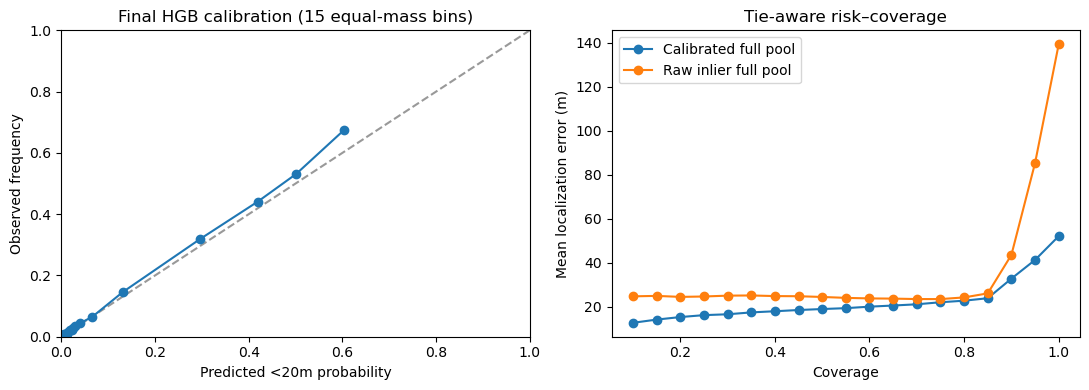

,coverage,calibrated_risk_m,raw_inlier_risk_m,improvement_m,relative_improvement,improvement_ci95_m
coverage_50,0.5,18.907544,24.399526,5.491983,0.225086,"[4.534394345980695, 6.345314620440324]"
coverage_70,0.7,21.059499,23.444563,2.385064,0.101732,"[1.793996716094875, 2.9918345527908583]"
coverage_90,0.9,32.74444,43.543035,10.798595,0.247998,"[-1.5769455407285664, 26.9121344556782]"


,value
coverage_min,0.1
coverage_max,1.0
calibrated_AURC_m,21.686563
raw_inlier_AURC_m,32.076379
improvement_m,10.389815
relative_improvement,0.323909
improvement_ci95_m,"[8.167839219025328, 13.056815702722485]"


In [11]:
final_records = [json.loads(line) for line in (RUN / 'full_test3443_frozen2000.jsonl').open() if line.strip()]
final_model = PoseLikelihoodCalibrator.load(RUN / 'final_fulltrain_hgb_calibrator.json')
final_candidates = [c for r in final_records for c in r['candidates']]
final_labels = np.asarray([c['success_20m'] for c in final_candidates], dtype=float)
final_probs = final_model.predict_proba_matrix(np.stack([feature_vector(c) for c in final_candidates]))
final_bins = np.array_split(np.argsort(final_probs), 15)
final_reliability = pd.DataFrame([{'probability': final_probs[b].mean(), 'success_rate': final_labels[b].mean()} for b in final_bins])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([0, 1], [0, 1], '--', color='0.6')
axes[0].plot(final_reliability.probability, final_reliability.success_rate, 'o-')
axes[0].set(xlabel='Predicted <20m probability', ylabel='Observed frequency', title='Final HGB calibration (15 equal-mass bins)', xlim=(0, 1), ylim=(0, 1))
curve = final_audit['AURC']['curve']
axes[1].plot(curve['coverage'], curve['calibrated_risk_m'], 'o-', label='Calibrated full pool')
axes[1].plot(curve['coverage'], curve['raw_inlier_risk_m'], 'o-', label='Raw inlier full pool')
axes[1].set(xlabel='Coverage', ylabel='Mean localization error (m)', title='Tie-aware risk–coverage')
axes[1].legend(); plt.tight_layout(); plt.show()
display(pd.DataFrame(final_audit['selective_risk']).T)
display(pd.Series(final_audit['AURC']['summary']).to_frame('value'))


### Runtime and official-evaluator status

Cache timing measures exhaustive VOP+matching, not adaptive latency. Official logs separately report VOP+matcher time; feature extraction and confidence-selection overhead outside these timers are not full end-to-end wall time.


In [12]:
display(pd.DataFrame([{'split': k, 'exhaustive_20_candidate_VOP_match_s/query': integrity[k]['mean_candidate_vop_match_time_s']} for k in ('train', 'test')]))
display(Markdown(f"Final offline adaptive cost: **{final_audit['mean_adaptive_hypotheses']:.3f} hypotheses/query**."))
official_path = RUN / 'official_fulltrain_20260904/official_summary.json'
if official_path.exists():
    official_summary = json.loads(official_path.read_text())
    display(official_summary)
else:
    display(Markdown('**Official matched reruns pending. These cached values are not headline paper results.**'))


,split,exhaustive_20_candidate_VOP_match_s/query
0,train,1.704974
1,test,1.762055


Final offline adaptive cost: **6.788 hypotheses/query**.

**Official matched reruns pending. These cached values are not headline paper results.**

## Takeaways

Preserve both the initial heuristic rejection and the later evidence; do not overwrite an unsuccessful experiment with the successful follow-up. The final offline gate below uses the previously agreed full-stage criteria and paired audit. Official matched reruns, not cached comparisons against older dense logs, are required before headline claims. Cross-area is not started by this notebook.


In [13]:
legacy = final_audit['strategies']['legacy_top1_vop']; adaptive = final_audit['strategies']['adaptive_calibrated']
full_checks = {'Dis_relative_reduction_ge_5pct': (legacy['Dis@1_m'] - adaptive['Dis@1_m']) / legacy['Dis@1_m'] >= .05, 'MA20_gain_ge_2pp': adaptive['MA@20_pct'] - legacy['MA@20_pct'] >= 2, 'worse_than_coarse_nonincrease': adaptive['worse_than_coarse_pct'] <= legacy['worse_than_coarse_pct'], 'catastrophic_nonincrease': adaptive['catastrophic_50m_pct'] <= legacy['catastrophic_50m_pct'], 'paired_statistical_audit_KEEP': final_audit['decision'] == 'KEEP'}
display(pd.Series(full_checks, name='passed').to_frame())
offline_decision = 'KEEP' if all(full_checks.values()) else 'REJECT'
display(Markdown(f"**Final full-train offline decision: `{offline_decision}`.** Historical fitter gate: `{final_summary['decision']}` (70%/15% heuristic). Official confirmation is reported separately above."))


,passed
Dis_relative_reduction_ge_5pct,True
MA20_gain_ge_2pp,True
worse_than_coarse_nonincrease,True
catastrophic_nonincrease,True
paired_statistical_audit_KEEP,True


**Final full-train offline decision: `KEEP`.** Historical fitter gate: `REJECT` (70%/15% heuristic). Official confirmation is reported separately above.